# 17.4.1 迁移到双室物质清除

## 学习目标与先修知识

把稀疏发现迁到双室守恒模型（model），与同观测（observation）的机制基线比较。

先修：3.2 多室交换；17.3 失效分析。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

在生命系统中看到良好短时预测，怎样同时检查交换项符号与总量收支（mass balance）？

In [1]:
import itertools
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先计算一个可手算的数值，再提出本节需要核验的主张。

In [2]:
A1,A2=2.,1.;e=.3;print("双室导数",[.2-.1*A1-e*(A1-A2),-.2*A2+e*(A1-A2)])

双室导数 [-0.3, 0.09999999999999998]


## 模型假设

将前面的方法迁移到双室交换与清除问题。两个室的状态（state）均为 U，时间为 T；输入（input）为 U/T，清除和交换率为 1/T。人工参数（parameter）只用于生成与独立核验；拟合模型不能读取评估真值。

## 数学解释与推导

$\dot A_1=u_1-k_1A_1-e(A_1-A_2)$，$\dot A_2=u_2-k_2A_2+e(A_1-A_2)$。相加得 $\dot A_1+\dot A_2=u_1+u_2-k_1A_1-k_2A_2$，交换项严格抵消。用同一观测和独立输入条件比较机制参数模型与稀疏多项式模型时，除 RMSE 还应检查总量收支及非负性（nonnegativity）。

## 核心实现

以下短函数展示方程、数值步骤和可修改的计算顺序。

In [3]:
def clearance_rhs(amounts,inputs,clearance,exchange):
    first,second=amounts;u1,u2=inputs;k1,k2=clearance
    return [u1-k1*first-exchange*(first-second),
            u2-k2*second+exchange*(first-second)]


def rk4_path(rhs, initial, h, steps):
    state=np.asarray(initial,dtype=float)
    rows=[state.copy()]
    for _ in range(steps):
        k1=np.asarray(rhs(state));k2=np.asarray(rhs(state+h*k1/2))
        k3=np.asarray(rhs(state+h*k2/2));k4=np.asarray(rhs(state+h*k3))
        state=state+h*(k1+2*k2+2*k3+k4)/6
        rows.append(state.copy())
    return np.asarray(rows)


def polynomial_library(states, degree=2):
    states=np.atleast_2d(np.asarray(states,dtype=float))
    terms=[()]
    for order in range(1,degree+1):
        terms.extend(itertools.combinations_with_replacement(range(states.shape[1]),order))
    matrix=np.column_stack([np.prod(states[:,indices],axis=1) if indices else np.ones(len(states)) for indices in terms])
    labels=['1' if not indices else '*'.join('xyz'[i] if i<3 else f'x{i}' for i in indices) for indices in terms]
    return matrix,labels


def stlsq(features, derivatives, threshold=.1, iterations=10):
    """Sequential thresholded least squares with an explicit refit per target."""
    X=np.asarray(features,dtype=float);Y=np.atleast_2d(np.asarray(derivatives,dtype=float))
    if Y.shape[0]!=X.shape[0]:Y=Y.T
    coefficients=np.linalg.lstsq(X,Y,rcond=None)[0]
    for _ in range(iterations):
        keep=np.abs(coefficients)>=threshold
        updated=np.zeros_like(coefficients)
        for column in range(Y.shape[1]):
            if keep[:,column].any():
                updated[keep[:,column],column]=np.linalg.lstsq(X[:,keep[:,column]],Y[:,column],rcond=None)[0]
        coefficients=updated
    return coefficients


def clearance_score(truth,prediction,total_input,total_removed,initial_total,final_total):
    truth=np.asarray(truth,dtype=float);pred=np.asarray(prediction,dtype=float)
    rmse=float(np.sqrt(np.mean((truth-pred)**2)))
    balance=float(abs(final_total-initial_total-total_input+total_removed))
    negative=int(np.sum(pred<0))
    return [rmse,balance,negative]

## 对照实验

用前 50 个训练状态拟合一次字典，将拟合方程与机制方程在同一初态、同一时间窗中的轨迹（trajectory）叠加。

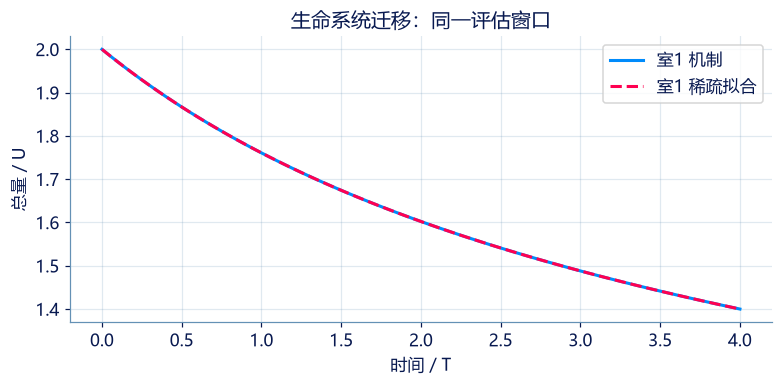

系数 [[ 0.2  0. ]
 [-0.4  0.3]
 [ 0.3 -0.5]]


In [4]:
initial=[2.,1.];inputs=[.2,0.];clear=[.1,.2];exchange=.3;rhs=lambda s:np.asarray(clearance_rhs(s,inputs,clear,exchange));truth=rk4_path(rhs,initial,.05,80);Phi,names=polynomial_library(truth[:50],1);Xi=stlsq(Phi,np.asarray([rhs(s) for s in truth[:50]]),.001,5);pred=rk4_path(lambda s:polynomial_library(s,1)[0][0]@Xi,initial,.05,80)
fig,ax=plt.subplots(figsize=(7,3.4));ax.plot(np.arange(81)*.05,truth[:,0],label="室1 机制",color=BLUE);ax.plot(np.arange(81)*.05,pred[:,0],"--",label="室1 稀疏拟合",color=PINK);ax.set(xlabel="时间 / T",ylabel="总量 / U",title="生命系统迁移：同一评估窗口");ax.legend();ax.grid(alpha=.2);plt.show();print("系数",Xi)

## 结果解释

一次字典能够表示双室模型中的输入、交换与清除，拟合轨迹因此贴近机制轨迹。将两室变化率相加，交换项相消，留下总输入减总清除；这也提供了检查所学方程的直接方法。

### 独立核对

在两个状态上分别相加两室变化率，检查交换抵消；再比较两条轨迹。

In [5]:
for state in [[2.,1.],[.3,1.8]]:
    rates=clearance_rhs(state,inputs,clear,exchange);np.testing.assert_allclose(sum(rates),sum(inputs)-sum(k*a for k,a in zip(clear,state)))
assert np.sqrt(np.mean((pred-truth)**2))<1e-4
print("交换抵消与解析结构核验通过。")

交换抵消与解析结构核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/17-04-%E7%A0%94%E7%A9%B6%E6%96%B9%E6%B3%95%E7%BB%BC%E5%90%88%E6%AF%94%E8%BE%83/explore/)。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：交换守恒

双室交换项相加后怎样变化？

- **A.** 变为两倍交换量
- **B.** 相互抵消，总量只受输入（input）与清除影响
- **C.** 总量必然不变
- **D.** 说明单室浓度（concentration）一致

[作答：交换守恒](http://127.0.0.1:8000/chapters/17-04-%E7%A0%94%E7%A9%B6%E6%96%B9%E6%B3%95%E7%BB%BC%E5%90%88%E6%AF%94%E8%BE%83/practice/?question=p17-c4s1-choice1)

### 第 2 题 · 单项选择题：论文任务边界

把 SINDy 用到双室人工清除模型（model）属于什么？

- **A.** 原文 Lorenz 原样复现
- **B.** 生命系统课程迁移，不是原 Lorenz 实验
- **C.** 临床有效性试验
- **D.** 无需独立核验的新发现

[作答：论文任务边界](http://127.0.0.1:8000/chapters/17-04-%E7%A0%94%E7%A9%B6%E6%96%B9%E6%B3%95%E7%BB%BC%E5%90%88%E6%AF%94%E8%BE%83/practice/?question=p17-c4s1-choice2)

### 第 3 题 · Python 计算题：双室收支变化率

在生命系统中看到良好短时预测，怎样同时检查交换项符号与总量收支（mass balance）？本题计算“双室收支变化率”：室1=u1-k1*A1-e*(A1-A2)；室2=u2-k2*A2+e*(A1-A2)。请按下方具名参数（parameter）和返回结构实现 solve。

**函数与代码模板**

```python
def solve(
    amounts: list[float],
    inputs: list[float],
    clearance: list[float],
    exchange: float,
) -> list[float]:
    # 按题给公式计算，保留全部返回项。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `amounts` | `list[float]` | 双室当前总量。 | U |
| `inputs` | `list[float]` | 双室输入（input）率。 | U/T |
| `clearance` | `list[float]` | 双室一阶清除率。 | 1/T |
| `exchange` | `float` | 对称交换率。 | 1/T |

**返回值**

直接返回 rates（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `rates` | `list[float]` | 两个室的总量变化率。 | U/T |

**计算规则**

室1=u1-k1*A1-e*(A1-A2)；室2=u2-k2*A2+e*(A1-A2)。

**约束与边界**

- 全部数值有限；列表规模不超过 100；按题给顺序返回。
- 输入满足模型（model）和矩阵（matrix）维度要求；不在函数内抽样或读取外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| amounts | 双室当前总量。 | [2.0, 1.0] | U |
| inputs | 双室输入（input）率。 | [0.2, 0.0] | U/T |
| clearance | 双室一阶清除率。 | [0.1, 0.2] | 1/T |
| exchange | 对称交换率。 | 0.3 | 1/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
amounts = [2.0, 1.0]
inputs = [0.2, 0.0]
clearance = [0.1, 0.2]
exchange = 0.3

result = solve(amounts, inputs, clearance, exchange)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| rates | 两个室的总量变化率。 | [-0.3, 0.09999999999999998] | U/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [-0.3, 0.09999999999999998]
```

**样例解释**

输入样例代入计算规则后得到所示输出（output）；室1=u1-k1*A1-e*(A1-A2)；室2=u2-k2*A2+e*(A1-A2)。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：双室收支变化率](http://127.0.0.1:8000/chapters/17-04-%E7%A0%94%E7%A9%B6%E6%96%B9%E6%B3%95%E7%BB%BC%E5%90%88%E6%AF%94%E8%BE%83/practice/?question=p17-two-compartment)

### 第 4 题 · Python 计算题：迁移的三项指标

在生命系统中看到良好短时预测，怎样同时检查交换项符号与总量收支（mass balance）？本题计算“迁移的三项指标”：残差（residual）为 abs(final_total-initial_total-total_input+total_removed)；负值严格按 prediction<0 计数。请按下方具名参数（parameter）和返回结构实现 solve。

**函数与代码模板**

```python
def solve(
    truth: list[float],
    prediction: list[float],
    total_input: float,
    total_removed: float,
    initial_total: float,
    final_total: float,
) -> list:
    # 按题给公式计算，保留全部返回项。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `truth` | `list[float]` | 共同测试的真实状态（state）。 | U |
| `prediction` | `list[float]` | 同序预测状态。 | U |
| `total_input` | `float` | 评估窗输入（input）积分。 | U |
| `total_removed` | `float` | 评估窗清除积分。 | U |
| `initial_total` | `float` | 起点总量。 | U |
| `final_total` | `float` | 终点总量。 | U |

**返回值**

直接返回 score（list）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `score` | `list` | RMSE、总量收支残差、负预测值个数。 | 混合 |

**计算规则**

残差为 abs(final_total-initial_total-total_input+total_removed)；负值严格按 prediction<0 计数。

**约束与边界**

- 全部数值有限；列表规模不超过 100；按题给顺序返回。
- 输入满足模型（model）和矩阵（matrix）维度要求；不在函数内抽样或读取外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| truth | 共同测试的真实状态（state）。 | [1.0, 2.0] | U |
| prediction | 同序预测状态。 | [1.0, -1.0] | U |
| total_input | 评估窗输入（input）积分。 | 0.5 | U |
| total_removed | 评估窗清除积分。 | 0.2 | U |
| initial_total | 起点总量。 | 3 | U |
| final_total | 终点总量。 | 3.3 | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
truth = [1.0, 2.0]
prediction = [1.0, -1.0]
total_input = 0.5
total_removed = 0.2
initial_total = 3.0
final_total = 3.3

result = solve(truth, prediction, total_input, total_removed, initial_total, final_total)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| score | RMSE、总量收支残差、负预测值个数。 | [2.1213203435596424, 1.6653345369377348e-16, 1] | 混合 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [2.1213203435596424,
                   1.6653345369377348e-16,
                   1]
```

**样例解释**

输入样例代入计算规则后得到所示输出（output）；残差为 abs(final_total-initial_total-total_input+total_removed)；负值严格按 prediction<0 计数。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：迁移的三项指标](http://127.0.0.1:8000/chapters/17-04-%E7%A0%94%E7%A9%B6%E6%96%B9%E6%B3%95%E7%BB%BC%E5%90%88%E6%AF%94%E8%BE%83/practice/?question=p17-transfer-score)

**原始参考**

[Brunton、Proctor 与 Kutz，arXiv:1509.03580v1](https://arxiv.org/abs/1509.03580v1)